In [ ]:
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [8]:
from msa.utils.paths import get_joined_dataset

DATA_PATH = get_joined_dataset()

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["article_date", "date", "price_date"],
)

df.head()

,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_hits,sentiment_present,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.91,2.0,True,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
3,2024-02-08 01:15:00+00:00,https://www.nbcnewyork.com/news/business/money...,"Jim Cramer says recent moves in Apple , Chipot...",English,nbcnewyork.com,https://media.nbcnewyork.com/2023/11/107113454...,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
4,2024-02-08 01:15:00+00:00,https://invezz.com/news/2024/02/07/disney-q1-e...,Disney Q1 earnings : dividend increased as DTC...,English,invezz.com,https://invezz.com/wp-content/uploads/2022/11/...,Apple,AAPL,2024-02-08,-0.76,1.0,True,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


In [ ]:
# Create Text from title (joined dataset has no 'Text' column)
df['Text'] = df['title'].fillna("").astype(str)

# Derive Sentiment labels from lexicon-based sentiment_score for evaluation
# (positive > 0.3, negative < -0.3, else neutral)
df['Sentiment'] = df['sentiment_score'].apply(
    lambda s: 'positive' if s > 0.3 else ('negative' if s < -0.3 else 'neutral')
)

X = df['Text'].to_list()
y = df['Sentiment'].to_list()

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
import numpy as np

preds = []
preds_proba = []
tokenizer_kwargs = {"padding": True, "truncation": True, "max_length": 512}

for x in X:
    with torch.no_grad():
        input_sequence = tokenizer(x, return_tensors="pt", **tokenizer_kwargs)
        logits = model(**input_sequence).logits
        scores = {
        k: v
        for k, v in zip(
            model.config.id2label.values(),
            scipy.special.softmax(logits.numpy().squeeze()),
        )
    }
    sentimentFinbert = max(scores, key=scores.get)
    probabilityFinbert = max(scores.values())
    preds.append(sentimentFinbert)
    preds_proba.append(probabilityFinbert)

preds = np.array(preds)
preds_proba = np.array(preds_proba)




In [15]:
print(f"Accuracy-Score: {accuracy_score(y, preds)}")

Accuracy-Score: 0.5909127205941068


In [16]:
print(classification_report(y, preds))

              precision    recall  f1-score   support

    negative       0.36      0.67      0.46      1384
     neutral       0.69      0.68      0.68      7356
    positive       0.55      0.40      0.46      3783

    accuracy                           0.59     12523
   macro avg       0.53      0.58      0.54     12523
weighted avg       0.61      0.59      0.59     12523



In [17]:
print(confusion_matrix(y, preds))

[[ 922  353  109]
 [1266 4979 1111]
 [ 408 1876 1499]]


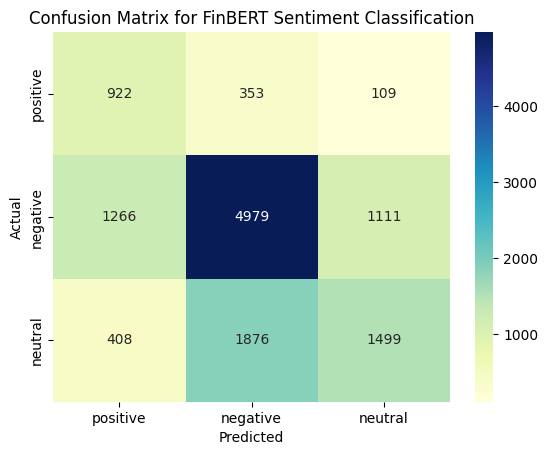

In [19]:
cm = confusion_matrix(y, preds)
cm_matrix = pd.DataFrame(data=cm, index=["positive", "negative", "neutral"], columns=["positive", "negative", "neutral"])

sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix for FinBERT Sentiment Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


